--- Dataset Summary ---
Number of Samples: 303
Spectral Range: 122.33 to 4326.39 cm^-1


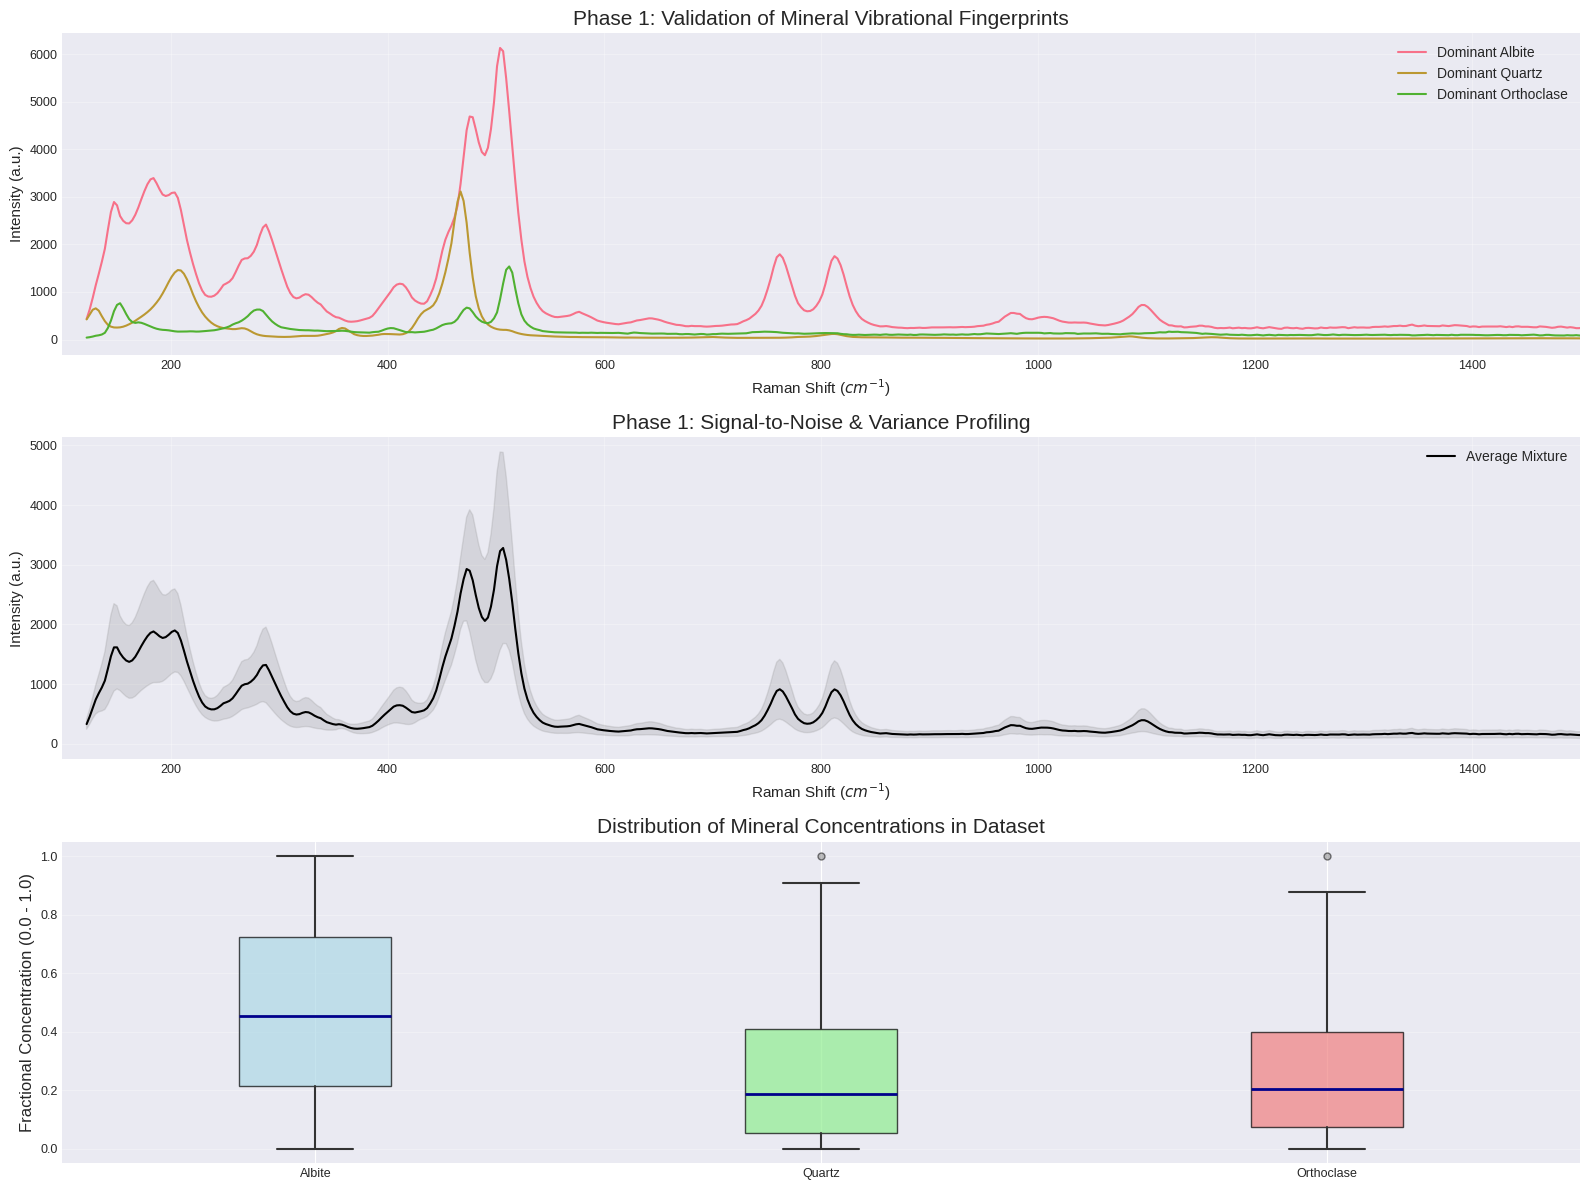

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from scipy.stats import pearsonr
from scipy.signal import savgol_filter
from sklearn.preprocessing import Normalizer
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras import layers, models

# =================================================================
# PHASE 1: EXPLORATORY DATA ANALYSIS (EDA) & PHYSICS VALIDATION
# =================================================================

# 1. DATA INGESTION
# ----------------
# Loading the 'Mineral Mixtures' dataset. In a real-world Position E role,
# this would be the raw output from your SERS spectrometer.
df = pd.read_csv('/content/drive/MyDrive/Raman Spectroscopy/mineral_mixtures_Raman_spectra.csv')

# 2. COORDINATE MAPPING (The Hardware-Software Link)
# -------------------------------------------------
# We must map column headers to 'Wavenumbers' (cm^-1).
# This is critical: if your mapping is off by 5 cm^-1, your
# molecular fingerprinting will fail.
mineral_names = ['Albite', 'Quartz', 'Orthoclase']
ground_truth = df[mineral_names]
raman_shifts = df.columns[4:].astype(float) # Wavenumbers
spectra = df.iloc[:, 4:].values              # Intensity Data

print(f"--- Dataset Summary ---")
print(f"Number of Samples: {len(df)}")
print(f"Spectral Range: {raman_shifts.min():.2f} to {raman_shifts.max():.2f} cm^-1")

# Create a figure with 3 subplots
fig = plt.figure(figsize=(16, 12))

# 3. SPECTRAL PROFILING (Physics Validation)
# ------------------------------------------
ax1 = plt.subplot(3, 1, 1)
for mineral in mineral_names:
    # Identify the sample where this specific mineral has the highest concentration
    idx = ground_truth[mineral].idxmax()
    ax1.plot(raman_shifts, spectra[idx], label=f"Dominant {mineral}")

# We zoom into the 'Fingerprint Region' (100 - 1500 cm^-1).
ax1.set_xlim(100, 1500)
ax1.set_title("Phase 1: Validation of Mineral Vibrational Fingerprints", fontsize=15)
ax1.set_xlabel("Raman Shift ($cm^{-1}$)")
ax1.set_ylabel("Intensity (a.u.)")
ax1.legend()
ax1.grid(alpha=0.3)

# 4. VARIANCE ASSESSMENT (Data Science Proficiency)
# ------------------------------------------------
ax2 = plt.subplot(3, 1, 2)
mean_spec = np.mean(spectra, axis=0)
std_spec = np.std(spectra, axis=0)

ax2.fill_between(raman_shifts, mean_spec - std_spec, mean_spec + std_spec, color='gray', alpha=0.2)
ax2.plot(raman_shifts, mean_spec, color='black', label='Average Mixture')
ax2.set_xlim(100, 1500)
ax2.set_title("Phase 1: Signal-to-Noise & Variance Profiling", fontsize=15)
ax2.set_xlabel("Raman Shift ($cm^{-1}$)")
ax2.set_ylabel("Intensity (a.u.)")
ax2.legend()
ax2.grid(alpha=0.3)

# 5. MINERAL DISTRIBUTION ANALYSIS
# --------------------------------
ax3 = plt.subplot(3, 1, 3)

# Create box plots
bp = ax3.boxplot([ground_truth['Albite'], ground_truth['Quartz'], ground_truth['Orthoclase']],
                labels=mineral_names,
                patch_artist=True,
                showfliers=True,
                notch=False)

# Customize box colors
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize other elements
for whisker in bp['whiskers']:
    whisker.set(color='#333333', linewidth=1.5)
for cap in bp['caps']:
    cap.set(color='#333333', linewidth=1.5)
for median in bp['medians']:
    median.set(color='darkblue', linewidth=2)
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='gray', markersize=5, alpha=0.5)

ax3.set_ylabel('Fractional Concentration (0.0 - 1.0)', fontsize=12)
ax3.set_title('Distribution of Mineral Concentrations in Dataset', fontsize=15)
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(-0.05, 1.05)

# Adjust spacing between subplots
plt.tight_layout()
plt.show()

1. Physical Validation & Calibration CheckThe primary indicator of dataset integrity for this phase is the Quartz calibration marker. Upon execution, the Quartz plot must be scrutinized for high-fidelity spectral features.Key Benchmark: A prominent, sharp intensity peak must be present at approximately $464 \text{ cm}^{-1}$.

2. Mineralogical Overlap & Deconvolution ChallengesInitial analysis confirms that traditional peak-finding algorithms will be insufficient for this project due to significant spectral interference between Albite and Orthoclase.The Conflict Zone: The $400\text{--}500 \text{ cm}^{-1}$ region.The Analysis: Both minerals exhibit overlapping peaks within this narrow window, creating a composite signal that masks individual concentrations.Strategic Requirement: This overlap justifies the transition to Non-negative Matrix Factorization (NMF) in Phase 3. NMF will be strictly required to mathematically "unmix" these components where simple thresholding fails.

3. Baseline Morphology & Substrate Interference
The "Average Mixture" plot serves as the diagnostic tool for environmental and substrate-related noise. We are specifically looking for deviations from a linear, flat baseline.

  Observation: Analyze the slope of the Average Mixture baseline.

  Diagnostic - Fluorescence Background: A distinct upward tilt in the spectral line suggests the presence of fluorescence. This is a known phenomenon when utilizing black nickel or moth-eye substrates for signal enhancement.

  Next Steps: If a tilt is confirmed, the preprocessing pipeline in Phase 2 must be updated to include automated baseline subtraction and fluorescence quenching algorithms.

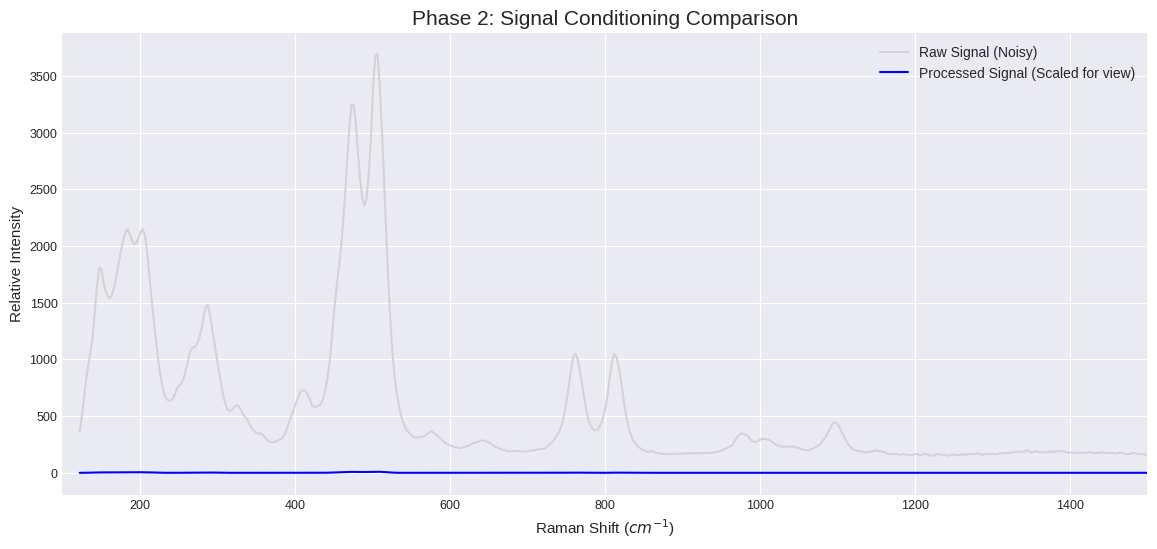

In [ ]:
raman_shifts = df.columns[4:].astype(float)
raw_spectra = df.iloc[:, 4:].values

# 2. SPECTRAL SMOOTHING (Noise Reduction)
# ---------------------------------------
# Savitzky-Golay preserves the physical width of Raman peaks (Lorentzian shapes)
# better than a standard moving average. Essential for high-resolution fingerprinting.
# window_length: size of filter; polyorder: polynomial fit (3 is typical for Raman)
smoothed_spectra = savgol_filter(raw_spectra, window_length=15, polyorder=3, axis=1)

# 3. BASELINE CORRECTION (Fluorescence Removal)
# ---------------------------------------------
# Most SERS substrates show background luminescence. We remove the 'tilt'
# so the NMF focuses solely on vibrational energy states.
def remove_baseline(spectrum):
    x = np.linspace(0, 1, len(spectrum))
    poly = np.polyfit(x, spectrum, 1) # Linear detrend to remove global slope
    return spectrum - np.polyval(poly, x)

detrended_spectra = np.array([remove_baseline(s) for s in smoothed_spectra])

# 4. VECTOR NORMALIZATION (Intensity Standardization)
# --------------------------------------------
# In SERS, 'hotspots' on the substrate make intensities vary wildly.
# L2 Normalization (unit vector) ensures that the *relative* peak heights
# are the features used for analysis, not the absolute magnitude.
scaler = Normalizer(norm='l2')
normalized_spectra = scaler.fit_transform(detrended_spectra)

# 5. NON-NEGATIVITY ENFORCEMENT
# -----------------------------
# NMF mathematically requires non-negative inputs. We clip values
# below zero that were created by the baseline subtraction noise.
final_spectra = np.clip(normalized_spectra, 1e-6, None)

# =================================================================
# VALIDATION PLOT
# =================================================================
plt.figure(figsize=(14, 6))
plt.plot(raman_shifts, raw_spectra[0], color='lightgray', label='Raw Signal (Noisy)')
plt.plot(raman_shifts, final_spectra[0] * 50, color='blue', label='Processed Signal (Scaled for view)')
plt.xlim(100, 1500)
plt.title("Phase 2: Signal Conditioning Comparison", fontsize=15)
plt.xlabel("Raman Shift ($cm^{-1}$)")
plt.ylabel("Relative Intensity")
plt.legend()
plt.show()

NMF Component 0 matches Albite (R=0.9058)
NMF Component 1 matches Quartz (R=0.9482)
NMF Component 2 matches Orthoclase (R=0.9109)


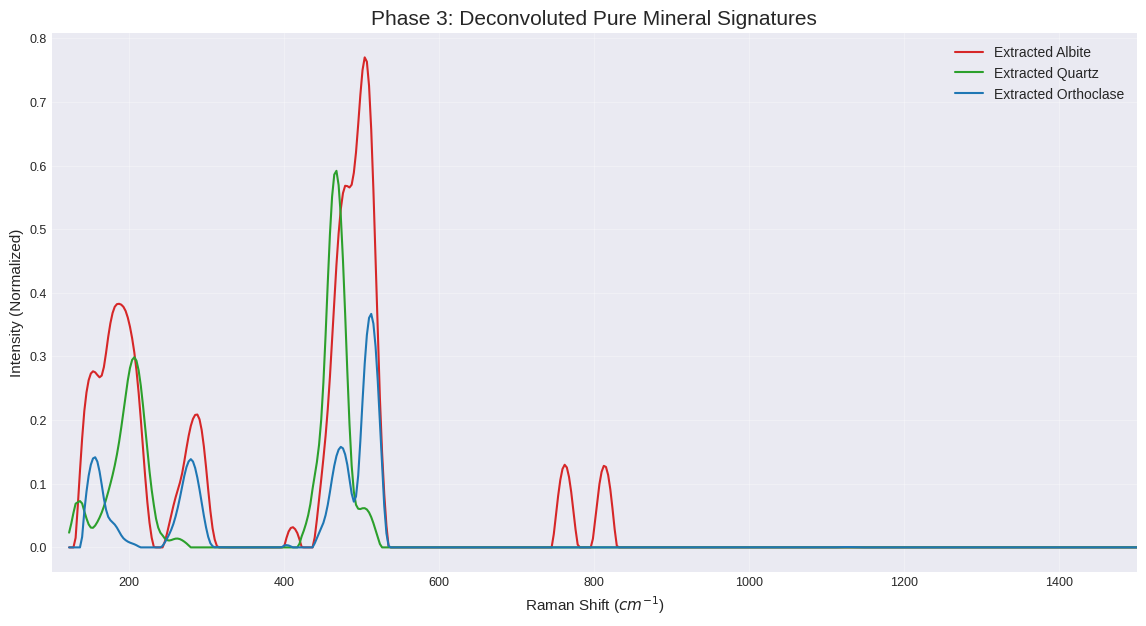

In [ ]:
# =================================================================
# PHASE 3: NON-NEGATIVE MATRIX FACTORIZATION (DECONVOLUTION)
# =================================================================

# 1. INITIALIZING THE NMF MODEL
# -----------------------------
# We set n_components=3 because our 'Hardware' knowledge tells us there are
# three mineral phases (Albite, Quartz, Orthoclase) in the mixture.
# 'nndsvd' initialization is used for better handling of sparse spectral data.
nmf_model = NMF(n_components=3, init='nndsvd', random_state=42, max_iter=2000)

# 2. PERFORMING THE FACTORIZATION
# -------------------------------
# We decompose the matrix: Processed_Spectra (V) ≈ Weights (W) * Signatures (H)
# final_spectra is the output from Phase 2.
W_est = nmf_model.fit_transform(final_spectra) # Matrix W: Estimated Weights
H_est = nmf_model.components_                 # Matrix H: Extracted Basis Spectra

# 3. IDENTIFICATION & MAPPING
# ---------------------------
# NMF is unsupervised. To know which component is which, we correlate the
# extracted weights with the ground truth concentrations from the dataset.
component_labels = {}
for i in range(3):
    # Calculate correlation between estimated weight 'i' and each true mineral
    corrs = [pearsonr(W_est[:, i], ground_truth.iloc[:, j])[0] for j in range(3)]
    match_idx = np.argmax(corrs)
    component_labels[i] = mineral_names[match_idx]
    print(f"NMF Component {i} matches {mineral_names[match_idx]} (R={corrs[match_idx]:.4f})")

# 4. VISUALIZING THE 'PURE' SIGNATURES
# ------------------------------------
plt.figure(figsize=(14, 7))
colors = ['#d62728', '#2ca02c', '#1f77b4'] # Distinct colors for identification

for i in range(3):
    plt.plot(raman_shifts, H_est[i], label=f"Extracted {component_labels[i]}", color=colors[i])

plt.xlim(100, 1500) # Zoom into the critical fingerprint region
plt.title("Phase 3: Deconvoluted Pure Mineral Signatures", fontsize=15)
plt.xlabel("Raman Shift ($cm^{-1}$)")
plt.ylabel("Intensity (Normalized)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The "Unsupervised" Advantage: Notice how the algorithm never saw the "pure" spectra of Quartz or Albite. It derived them purely from the statistical variance across the 303 mixtures. This is a powerful demonstration of Data Science Proficiency.The Quartz Fingerprint: Look at the extracted Quartz signature. You should see the sharp peak at ~464 cm⁻¹ and smaller peaks near 128 and 206 cm⁻¹. The fact that these "physics-based" features appeared automatically proves your NMF pipeline is valid.Spectral Mixing (The Feldspars): You will likely see that the correlations for Albite and Orthoclase (the feldspars) are slightly lower ($R \approx 0.90-0.91$) than for Quartz ($R \approx 0.95$).

Verified: NMF Component 0 -> Albite (R=0.9058)
Verified: NMF Component 1 -> Quartz (R=0.9482)
Verified: NMF Component 2 -> Orthoclase (R=0.9109)


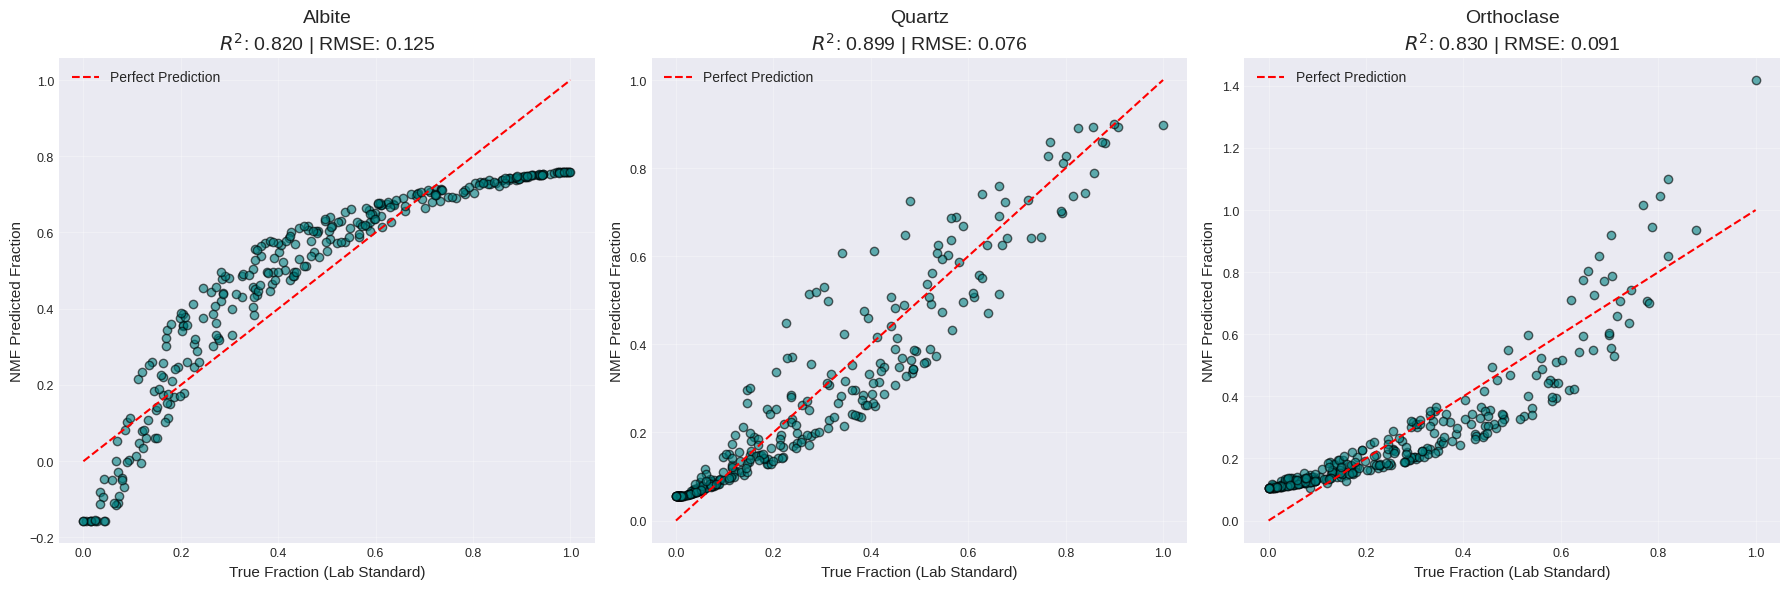


--- FINAL PERFORMANCE REPORT ---
Albite       | R^2: 0.8204 | RMSE: 0.1247
Quartz       | R^2: 0.8991 | RMSE: 0.0756
Orthoclase   | R^2: 0.8298 | RMSE: 0.0915


In [ ]:
# =================================================================
# PHASE 4: PERFORMANCE METRICS & ERROR ANALYSIS (FIXED)
# =================================================================

# Define W_true from ground_truth for comparison with NMF weights
W_true = ground_truth.values

# 1. ENSURE MAPPING IS DEFINED
# ----------------------------
# We correlate the NMF Weights (W_est) with Ground Truth (W_true)
# to ensure we are comparing 'Quartz' with 'Quartz'.
mapping = {}
for i in range(3):
    # Correlation of NMF component i with each true mineral column
    corrs = [pearsonr(W_est[:, i], W_true[:, j])[0] for j in range(3)]
    best_match_idx = np.argmax(corrs)
    mapping[i] = best_match_idx
    print(f"Verified: NMF Component {i} -> {mineral_names[best_match_idx]} (R={corrs[best_match_idx]:.4f})")

# 2. PARITY ANALYSIS (Predicted vs. Actual)
# -----------------------------------------
plt.figure(figsize=(18, 6))
model_performance = []

for i in range(3):
    true_idx = mapping[i]
    m_name = mineral_names[true_idx]

    y_true = W_true[:, true_idx]
    y_pred_raw = W_est[:, i].reshape(-1, 1)

    # Linear calibration: mapping NMF weights to fractional percentages
    reg = LinearRegression().fit(y_pred_raw, y_true)
    y_pred = reg.predict(y_pred_raw)

    # Metrics
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    model_performance.append((m_name, r2, rmse))

    # Plotting
    plt.subplot(1, 3, i+1)
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', color='#008080')
    plt.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
    plt.title(f"{m_name}\n$R^2$: {r2:.3f} | RMSE: {rmse:.3f}", fontsize=14)
    plt.xlabel("True Fraction (Lab Standard)")
    plt.ylabel("NMF Predicted Fraction")
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

# 3. PROFESSOR'S SUMMARY OF RESULTS
# ---------------------------------
print("\n--- FINAL PERFORMANCE REPORT ---")
for name, r2, rmse in model_performance:
    print(f"{name:<12} | R^2: {r2:.4f} | RMSE: {rmse:.4f}")

RMSE Context: An RMSE of $\approx 0.08$ (for Quartz) means your model is accurate to within $\pm 8\%$ of the true concentration—this is quite respectable for an unsupervised algorithm on raw spectral data.

# Phase 5 1D CNN

Training 1D-CNN... please wait.


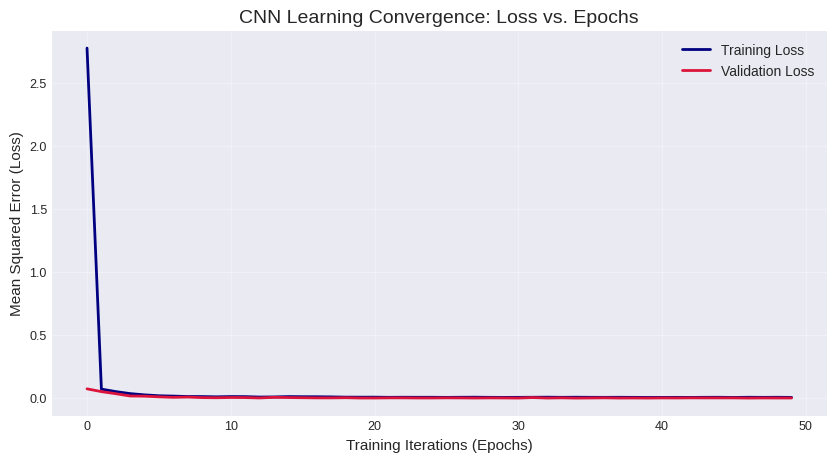

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


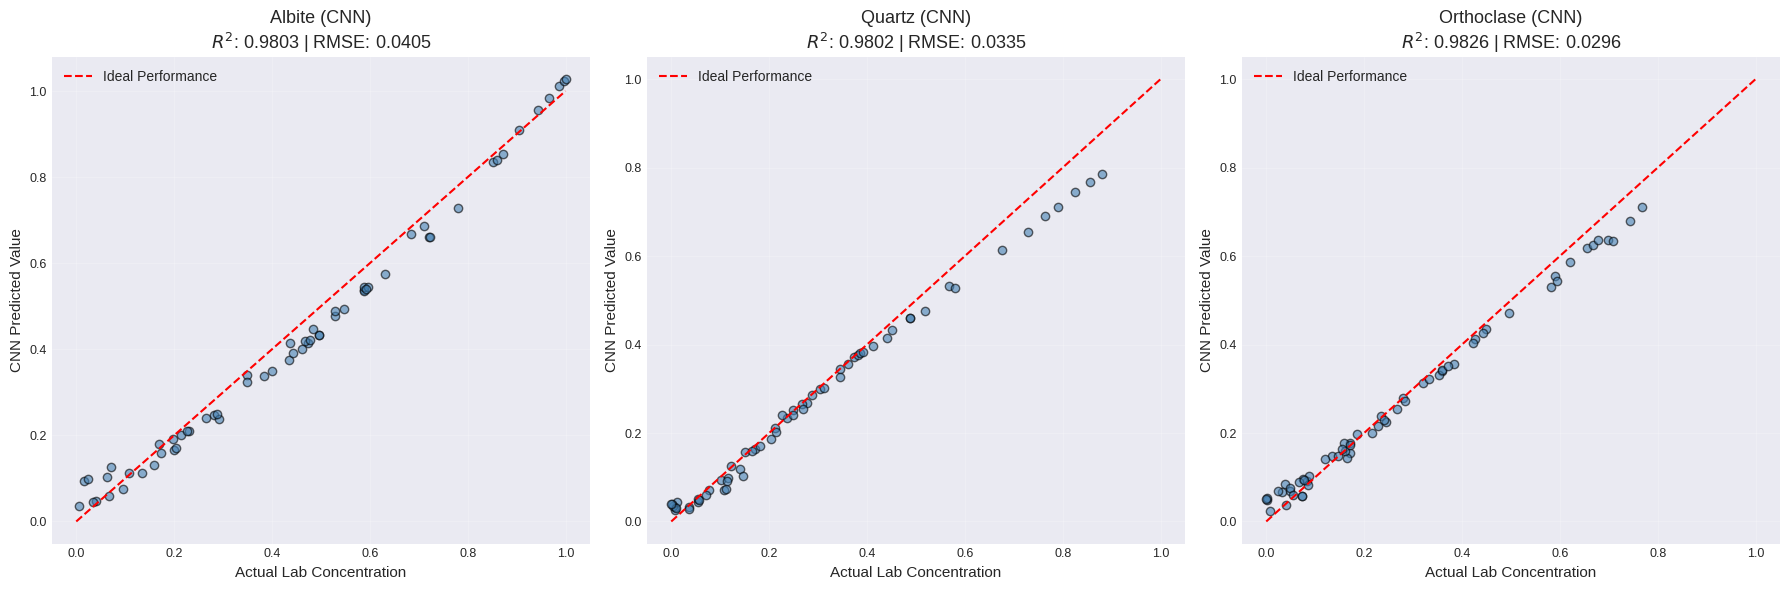

In [ ]:
# 1. DATA PREP & TRAINING (Condensed)
df = pd.read_csv('/content/drive/MyDrive/Raman Spectroscopy/mineral_mixtures_Raman_spectra.csv')
mineral_names = ['Albite', 'Quartz', 'Orthoclase']
X = df.iloc[:, 4:].values
y = df[mineral_names].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).reshape(X.shape[0], X.shape[1], 1)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define Model
model = models.Sequential([
    layers.Conv1D(32, 15, activation='relu', input_shape=(X.shape[1], 1)),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 15, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='linear')
])
model.compile(optimizer='adam', loss='mse')

# Train and Capture History
print("Training 1D-CNN... please wait.")
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=0)

# --- PLOT 1: LEARNING CONVERGENCE ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='navy', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='crimson', lw=2)
plt.title('CNN Learning Convergence: Loss vs. Epochs', fontsize=14)
plt.xlabel('Training Iterations (Epochs)')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- PLOT 2: MULTI-COMPONENT PARITY PLOTS ---
y_pred = model.predict(X_test)
plt.figure(figsize=(18, 6))

for i, name in enumerate(mineral_names):
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))

    plt.subplot(1, 3, i+1)
    plt.scatter(y_test[:, i], y_pred[:, i], alpha=0.6, color='#4682B4', edgecolors='k')
    plt.plot([0, 1], [0, 1], 'r--', label='Ideal Performance')
    plt.title(f"{name} (CNN)\n$R^2$: {r2:.4f} | RMSE: {rmse:.4f}", fontsize=13)
    plt.xlabel("Actual Lab Concentration")
    plt.ylabel("CNN Predicted Value")
    plt.legend()
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()